In [1]:
import pandas as pd
from datetime import datetime

## Read training and test datasets

In [2]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [3]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [4]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [5]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


In [6]:
df_train = df_train.sort_values('Date').reset_index(drop=True)
df_test  = df_test.sort_values('Date').reset_index(drop=True)

features = ['Open','Low','High','Close','Volume']

X_train = df_train[features].shift(1).iloc[1:].values
y_train = df_train['Close'].iloc[1:].values

X_test = df_test[features].shift(1).iloc[1:].values
y_test = df_test['Close'].iloc[1:].values

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model    import LinearRegression
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm             import SVR
from sklearn.neighbors       import KNeighborsRegressor
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline      import make_pipeline
from sklearn.metrics import mean_squared_error

models = [
    ('LinearReg',     LinearRegression()),
    ('RandomForest',  RandomForestRegressor(random_state=42)),
    ('KNN',           KNeighborsRegressor(n_neighbors=1)),
    ('Poly2',            make_pipeline(
                             PolynomialFeatures(degree=2, include_bias=False),
                             LinearRegression()
                       )),
]

tscv = TimeSeriesSplit(n_splits=5)
scores_dict = {}  

for name, model in models:
    neg_mses = cross_val_score(model, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-neg_mses)
    print(f"{name} CV RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
    scores_dict[name] = cv_rmse.mean()
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    test_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
    print(f"{name} Test RMSE: {test_rmse:.2f}\n")

best_name = min(scores_dict, key=scores_dict.get)
best_model = dict(models)[best_name]
print(f"\n>> Best Model: {best_name}")
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
test_rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
from sklearn.metrics import r2_score
test_r2   = r2_score(y_test, y_pred)
print(f"Best Model Test RMSE: {test_rmse:.2f}, Test R2: {test_r2:.3f}")

LinearReg CV RMSE: 32.46 ± 3.10
LinearReg Test RMSE: 24.23

RandomForest CV RMSE: 147.15 ± 116.49
RandomForest Test RMSE: 27.42

KNN CV RMSE: 517.42 ± 233.50
KNN Test RMSE: 276.13

Poly2 CV RMSE: 45.77 ± 13.48
Poly2 Test RMSE: 24.66


>> Best Model: LinearReg
Best Model Test RMSE: 24.23, Test R2: 0.923


LinearReg Test RMSE: 24.23
RandomForest Test RMSE: 27.42
KNN Test RMSE: 276.13
Poly2 Test RMSE: 24.66


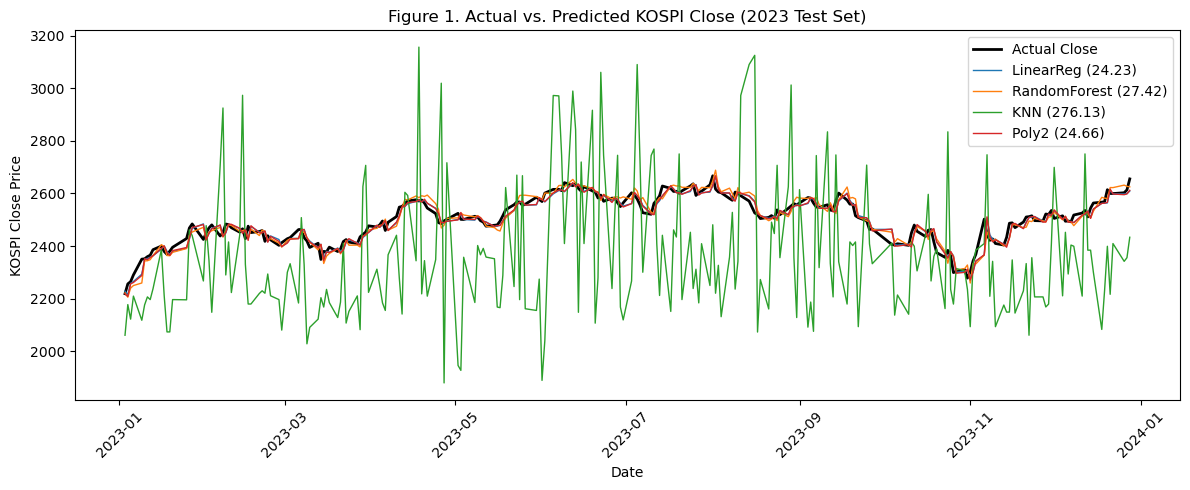

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

dates = df_test['Date'].iloc[1:].reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(dates, y_test, label='Actual Close', color='k', linewidth=2)

for name, model in models:
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f"{name} Test RMSE: {rmse:.2f}")
    plt.plot(dates, preds, label=f"{name} ({rmse:.2f})", linewidth=1)

plt.title('Figure 1. Actual vs. Predicted KOSPI Close (2023 Test Set)')
plt.xlabel('Date')
plt.ylabel('KOSPI Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 

In [8]:
#MA_5 is the 5-day moving average of the closing price.
# By including MA_5 as an additional feature,
# we aim to demonstrate a reduction in the model’s RMSE.
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [9]:
df_train['MA_6'] = df_train['Close'].rolling(window=6).mean()
df_test['MA_6']  = df_test['Close'].rolling(window=6).mean()

df_train_6 = df_train.dropna().reset_index(drop=True)
df_test_6  = df_test.dropna().reset_index(drop=True)

features_6 = ['Open', 'Low', 'High', 'Close', 'Volume', 'MA_6']
X_train_6 = df_train_6[features_6].shift(1).iloc[1:].values
y_train_6 = df_train_6['Close'].iloc[1:].values
X_test_6  = df_test_6[features_6].shift(1).iloc[1:].values
y_test_6  = df_test_6['Close'].iloc[1:].values

tscv = TimeSeriesSplit(n_splits=5)
for name, model in [
    ('LinearReg',    LinearRegression()),
    ('RandomForest', RandomForestRegressor(random_state=42)),
    ('KNN',           KNeighborsRegressor(n_neighbors=1)),
]:
    neg_mses = cross_val_score(model, X_train_6, y_train_6,
                               cv=tscv, scoring='neg_mean_squared_error')
    rmses = np.sqrt(-neg_mses)
    print(f"{name} + MA_6 CV RMSE: {rmses.mean():.2f} ± {rmses.std():.2f}")

    model.fit(X_train_6, y_train_6)
    y_pred = model.predict(X_test_6)
    test_rmse = np.sqrt(mean_squared_error(y_test_6, y_pred))
    print(f"{name} + MA_6 Test RMSE: {test_rmse:.2f}\n")

LinearReg + MA_6 CV RMSE: 32.13 ± 2.93
LinearReg + MA_6 Test RMSE: 24.06

RandomForest + MA_6 CV RMSE: 130.96 ± 86.93
RandomForest + MA_6 Test RMSE: 26.52

KNN + MA_6 CV RMSE: 512.77 ± 227.08
KNN + MA_6 Test RMSE: 270.56



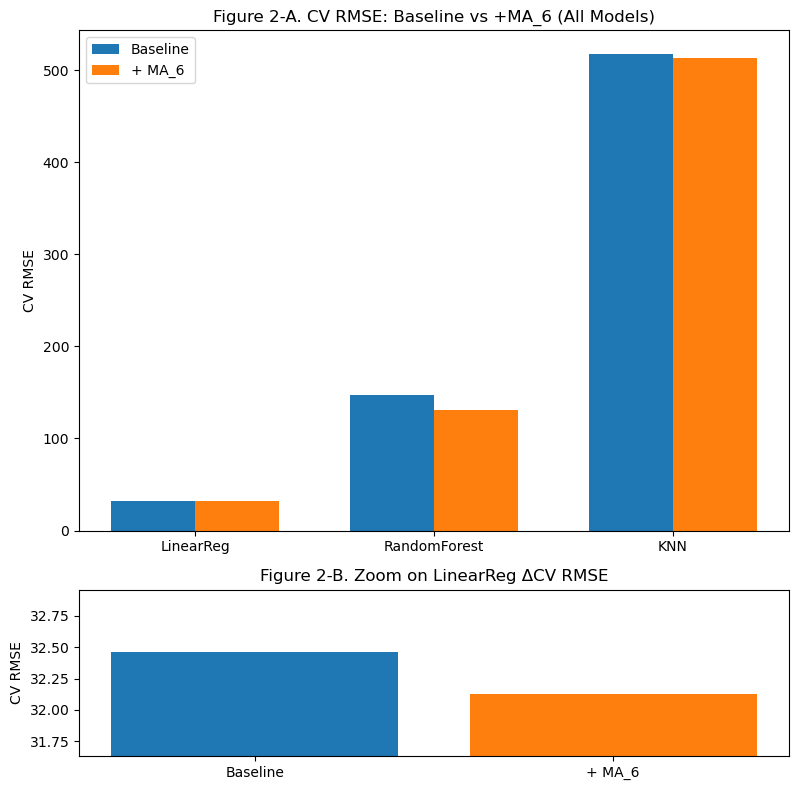

In [10]:
import matplotlib.pyplot as plt
import numpy as np

baseline_cv = {
    'LinearReg':     32.46,
    'RandomForest': 147.15,
    'KNN':          517.42
}
ma6_cv = {
    'LinearReg':     32.13,
    'RandomForest': 130.96,
    'KNN':          512.77
}

models = list(baseline_cv.keys())
x = np.arange(len(models))
width = 0.35

fig, axs = plt.subplots(2, 1, figsize=(8, 8),
                        gridspec_kw={'height_ratios': [3, 1]})

axs[0].bar(x - width/2,
           [baseline_cv[m] for m in models],
           width, label='Baseline')
axs[0].bar(x + width/2,
           [ma6_cv[m]    for m in models],
           width, label='+ MA_6')
axs[0].set_xticks(x)
axs[0].set_xticklabels(models)
axs[0].set_ylabel('CV RMSE')
axs[0].set_title('Figure 2-A. CV RMSE: Baseline vs +MA_6 (All Models)')
axs[0].legend()

vals = [baseline_cv['LinearReg'], ma6_cv['LinearReg']]
axs[1].bar(['Baseline','+ MA_6'], vals, color=['C0','C1'])
ymin = min(vals) - 0.5
ymax = max(vals) + 0.5
axs[1].set_ylim(ymin, ymax)
axs[1].set_ylabel('CV RMSE')
axs[1].set_title('Figure 2-B. Zoom on LinearReg ΔCV RMSE')

plt.tight_layout()
plt.show()
